In [12]:
import pocam_light
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import hephaistos as hp
#hp.selectDevice(0)
import hephaistos.pipeline as pl
from theia.volume import Attenuating
import theia
import theia.units as u
from pathlib import Path
from theia.compiler import addIncludeDir
from LayerMediumModel import LayerMediumModel
addIncludeDir(Path("shader"))
import numpy as np
import matplotlib.pyplot as plt
import hephaistos.pipeline as pl
import theia
import theia.units as u
import pocam_light

from theia.volume import Attenuating
from theia.ray import UnpolarizedRay

In [13]:
data = np.loadtxt("icemodel.dat")
layer_idx = 123

depth = data[layer_idx, 0]
be400 = data[layer_idx, 1]
adust400 = data[layer_idx, 2]
delta_tau = data[layer_idx, 3]

### Eismodell

In [14]:
alpha = 0.898608505726
kappa = 1.084106802940
A = 6954.090332031250
B = 6617.754394531250

g = 0.9
n = 1.35
ng = 1.35

model = LayerMediumModel(
    be400=be400,
    adust400=adust400,
    delta_tau=delta_tau,
    alpha=alpha,
    kappa=kappa,
    A=A,
    B=B,
    g=g,
    n=n,
    ng=ng,
    name="Eisschicht",
)

medium = model.createMedium(
    physicModel=Attenuating()
)

store = theia.material.MaterialStore(
    [],
    media=[medium],
)

### Target

In [15]:
rng = theia.random.PhiloxRNG(key=0xABBA)

wavelengthSource = theia.light.ConstWavelengthSource(
    wavelength
)

target = theia.target.SphereTarget(
    position=(
        31.25,
        -72.9300003051757,
        -383.3999938964844,
    ) * u.m,
    radius=0.5 * u.m,
)

response = theia.response.HistogramHitResponse(
    theia.response.UniformValueResponse(),
    binCount=200,
    binSize=2.0 * u.ns,
    t0=90.0 * u.ns,
)

### Lichtquelle

In [16]:
light_position = (
    46.9072,
    -56.5889,
    -385.93,
)

sphereLight = pocam_light.PocamLightSource(
    wavelengthSource,
    mediumIdx=store.media["Eisschicht"],
    position=light_position,
)

### Ray Tracer

In [17]:
batchSize = 1_000_000

ray = UnpolarizedRay()

sphereTracer = theia.trace.VolumeForwardTracer(
    batchSize,
    ray,
    sphereLight,
    target,
    response,
    rng,
    store,
    volume="Eisschicht",
    maxPathLength=1000,
    disableTargetSampling=False,
)

### Pipeline

In [18]:
spherePipeline = pl.Pipeline(
    sphereTracer.collectStages()
)

hists = []
def process(config: int, batch: int, args: None) -> None:
    hists.append(
        response.result(config).copy()
    )


pipelineMap = {
    "sphere": spherePipeline,
}

scheduler = pl.PipelineScheduler(
    pipelineMap,
    processFn=process,
)


### Simulation

In [19]:
tasks = [
    (
        "sphere",
        {
            "lightSource__budget": 1e10,
            "lightSource__position": (
                46.9072,
                -56.5889,
                -385.93,
            ) * u.m,
        },
    ),
    ("sphere", {}),
    ("sphere", {}),
    ("sphere", {}),
    ("sphere", {}),
]

scheduler.schedule(tasks)
scheduler.wait()

### Histogramm


Histogram sum: 1337996.7584396095


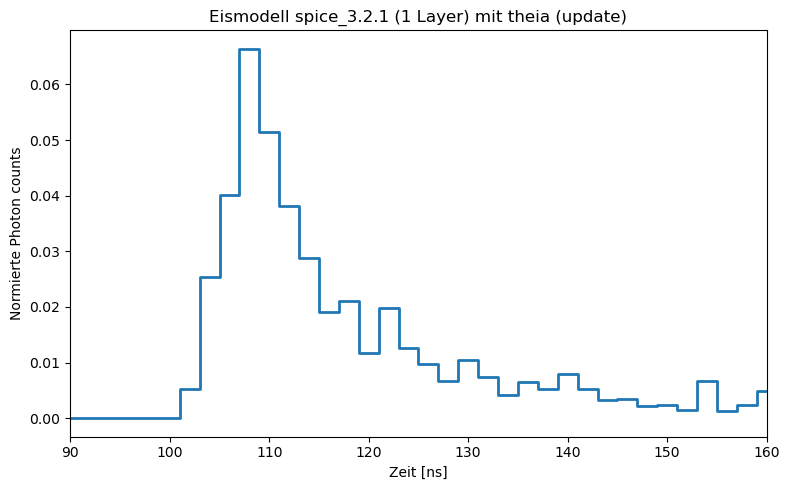

In [20]:
t = (
    np.arange(response.binCount)
    * response.binSize
    + response.t0
) / u.ns

sphereSignal = np.mean(hists[:50], axis=0)

sphereSignalNorm = sphereSignal / (
    np.sum(sphereSignal)
    * response.binSize
    / u.ns
)


print("\nHistogram sum:", np.sum(sphereSignal))

plt.figure(figsize=(8,5))
plt.step(
    t,
    sphereSignalNorm,
    where="mid",
    linewidth=2,
    label="Spherical source"
)
plt.xlabel("Zeit [ns]")
plt.ylabel("Normierte Photon counts")
plt.title(r"Eismodell spice_3.2.1 (1 Layer) mit theia (update)")
plt.xlim(90,160)
plt.tight_layout()
plt.savefig("withscattering_onelayer_update.pdf")
plt.show()


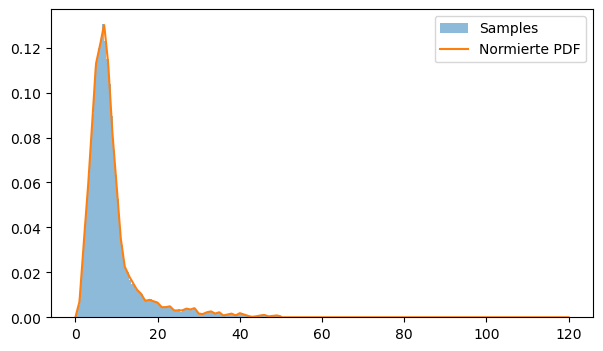

In [65]:
# Test, ob NumericalInversePolynomial die richtige Wahrscheinlichkeitsverteilung samplet

from scipy.stats.sampling import NumericalInversePolynomial
import numpy as np
import matplotlib.pyplot as plt
from pocam_light import _the_pulse

class Dist:
    def pdf(self, x):
        return _the_pulse(x, 15.0) 
                                   #NumericalInversePolynomial() erwartet nämlich ein Objekt das von Dist() erzeugt
                                   #wird und eine Methode pdf(x) besitzt

inv_cdf = NumericalInversePolynomial(
    Dist(),
    domain=(0.0, 120.0),              #erwartet ein Objekt mit Mehode
)
samples = inv_cdf.rvs(size=100000)

plt.figure(figsize=(7,4))

x = np.linspace(0,120,1000)

pdf = _the_pulse(x, 15)
pdf /= np.trapezoid(pdf, x)   # Nomirern!!

plt.hist(samples, bins=100, density=True, alpha=0.5, label="Samples") # density= TRue zur Normierung
plt.plot(x, pdf, label="Normierte PDF")

plt.legend()
plt.show()

In [ ]:
#Test, ob die Pocam-Lightsource funktioniert und Vergl. der Zeiten mit den zeiten der pulse_fkt

import pytest

import numpy as np
import scipy.integrate as integrate
import scipy.stats as stats

import hephaistos as hp
from hephaistos.pipeline import Pipeline, PipelineScheduler, runPipeline
from hephaistos.queue import dumpQueue
from ctypes import Structure, c_float

import theia.light
import theia.units as u
from theia.compiler import compileShader
from theia.material import MaterialStore, PureWaterModel, VACUUM_IDX
from theia.random import PhiloxRNG
from theia.ray import UnpolarizedRay
from theia.testing import BackwardLightSampler

N = 32 * 256
position = (14.0, -2.0, 3.0) * u.m
budget = 12.0

ray = UnpolarizedRay()
philox = PhiloxRNG(key=0xC0110FFC0FFEE)

photons = theia.light.ConstWavelengthSource(
    wavelength=100.0 * u.nm
)

light = pocam_light.PocamLightSource(
    photons,
    position=position,
    budget=budget,
    mediumIdx=VACUUM_IDX,
)

sampler = theia.light.LightSampler(
    N,
    light,
    ray,
    rng=philox,
)

runPipeline(sampler.collectStages())

result = sampler.queue.view(0)

plt.figure(figsize=(8,5))
plt.hist(times, bins=100, density=True, alpha=0.5, label="PocamLightSource")

x = np.linspace(0,120,1000)
pdf = _the_pulse(x,15)
pdf /= np.trapezoid(pdf, x)

plt.plot(x, pdf, lw=2, label=" _the_pulse (normiet)")

plt.legend()
plt.show()


In [ ]:
!git --version